In [1]:
import pandas as pd
df=pd.read_csv('sales_data.csv')

In [2]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [4]:
df.shape

(1000, 14)

In [5]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df.Product_Category.unique()

array(['Furniture', 'Food', 'Clothing', 'Electronics'], dtype=object)

In [8]:
df['Profit']=(df.Unit_Price - df.Unit_Cost)*df.Quantity_Sold

In [9]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Profit
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2060.46
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,6681.85
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,3295.20
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,5371.08
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,719.42


In [10]:
df.Profit.describe()

count     1000.000000
mean      6487.847070
std       5444.188837
min         17.360000
25%       1892.302500
50%       5236.825000
75%       9935.082500
max      23441.110000
Name: Profit, dtype: float64

## profit scatter plot showing there is outlier

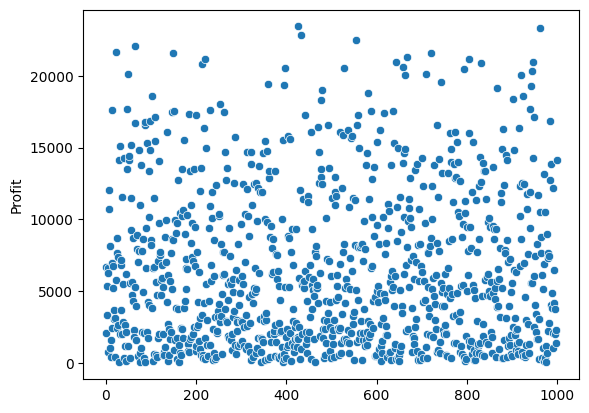

In [20]:
sns.scatterplot(data=df.Profit)
plt.show()

In [21]:
grouped_profit=df.groupby('Product_Category')['Profit'].sum()

## the most product profit

<Axes: xlabel='Product_Category', ylabel='Profit'>

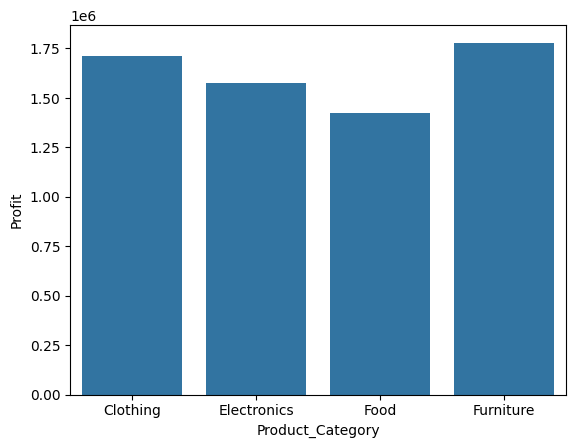

In [22]:
sns.barplot(data=grouped_profit)

In [14]:
print(grouped_profit)

Product_Category
Clothing       1712957.80
Electronics    1574320.06
Food           1421108.05
Furniture      1779461.16
Name: Profit, dtype: float64


In [15]:
par_region=pd.pivot_table(df,
                          values='Profit',
                         index='Region',
                        columns='Product_Category',
                         aggfunc='sum',)

In [16]:
print(par_region)

Product_Category   Clothing  Electronics       Food  Furniture
Region                                                        
East              443862.59    408297.93  413456.75  384939.93
North             442918.12    455265.62  272402.47  490874.99
South             392809.07    362884.11  400033.28  364010.44
West              433368.02    347872.40  335215.55  539635.80


## profit by region and product category

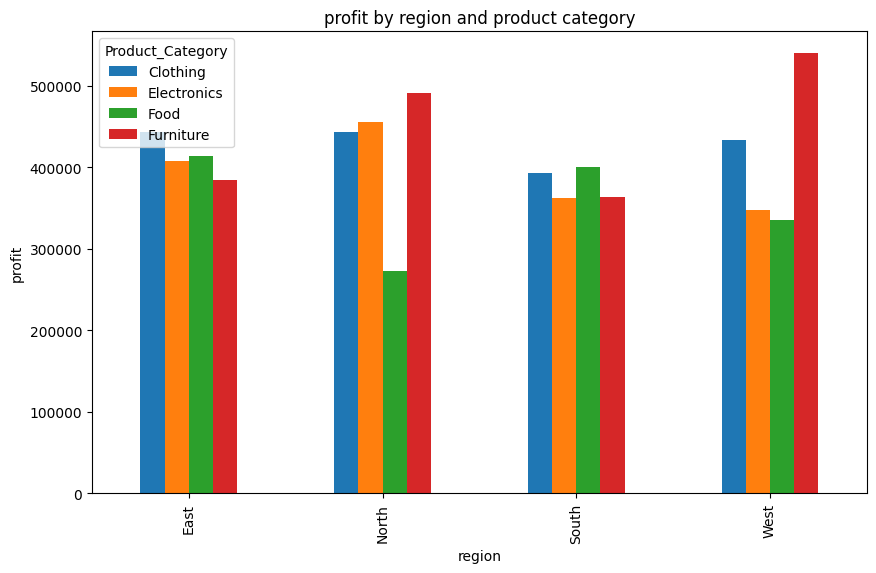

In [17]:
par_region.plot(kind='bar',figsize=(10,6))
plt.title('profit by region and product category')
plt.xlabel('region')
plt.ylabel('profit')
plt.show()

In [18]:
Customer=df[df['Customer_Type']=='New'].groupby('Product_Category')['Profit'].sum()

## products attracting new customers

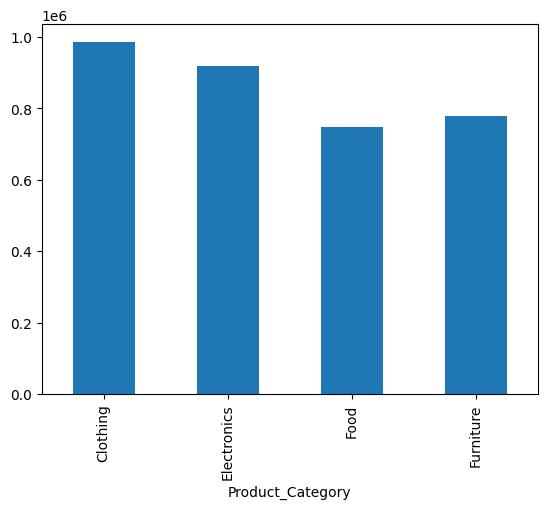

In [19]:
Customer.plot(kind='bar')
plt.show()

## Conclusion

The scatter plot shows that 75% of profits are below 9,935, with some high outliers present.
2. Furniture generates the highest overall profit, followed by clothing. However, clothing is the top category for attracting new customers.
3. Regional analysis shows that the West and North branches perform best in furniture, the East branch leads in clothing, and the South branch leads in food. Notably, furniture sales are significantly weaker in the South and East branches.
In conclusion, to maximize profits the business should focus on furniture as it generates the highest profit margin, while investing in clothing to attract new customers